In [155]:
import pandas as pd

df_original = pd.read_csv("Medical_appointment_data.csv")

df = df_original.copy()          # for ML
df_forecast = df_original.copy() # for time series

In [117]:
df

,specialty,appointment_time,gender,no_show,disability,place,appointment_shift,age,under_12_years_old,over_60_years_old,...,storm_day_before,rain_intensity,heat_intensity,appointment_date_continuous,Hipertension,Diabetes,Alcoholism,Handcap,Scholarship,SMS_received
0,psychotherapy,17,F,yes,intellectual,Lake Marvinville,afternoon,9.0,1,0,...,1,no_rain,warm,2020-01-01,0,0,0,0,0,0
1,NaN,7,M,no,intellectual,ITAPEMA,morning,11.0,1,0,...,1,no_rain,cold,2020-01-01,0,0,0,0,0,0
2,speech therapy,16,M,no,intellectual,ITAJAÍ,afternoon,8.0,1,0,...,1,no_rain,warm,2020-01-01,0,0,0,0,0,0
3,speech therapy,14,M,yes,intellectual,Sarahside,afternoon,9.0,1,0,...,1,moderate,mild,2020-01-01,0,0,0,0,0,1
4,physiotherapy,8,M,no,motor,ITAJAÍ,morning,NaN,0,0,...,1,no_rain,mild,2020-01-01,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109588,psychotherapy,16,M,yes,intellectual,NaN,afternoon,18.0,0,0,...,1,no_rain,mild,2021-05-11,0,0,0,0,0,0
109589,speech therapy,9,F,yes,motor,Port Georgestad,morning,18.0,0,0,...,1,moderate,warm,2021-05-11,0,0,0,0,0,0
109590,psychotherapy,13,F,no,intellectual,Erinton,afternoon,8.0,1,0,...,1,moderate,mild,2021-05-11,0,0,0,0,0,1
109591,physiotherapy,8,F,no,motor,CAMBORIU,morning,7.0,1,0,...,1,no_rain,warm,2021-05-11,0,0,0,0,0,0


In [118]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109593 entries, 0 to 109592
Data columns (total 26 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   specialty                    89466 non-null   object 
 1   appointment_time             109593 non-null  int64  
 2   gender                       109593 non-null  object 
 3   no_show                      109593 non-null  object 
 4   disability                   92992 non-null   object 
 5   place                        98054 non-null   object 
 6   appointment_shift            109593 non-null  object 
 7   age                          86633 non-null   float64
 8   under_12_years_old           109593 non-null  int64  
 9   over_60_years_old            109593 non-null  int64  
 10  patient_needs_companion      109593 non-null  int64  
 11  average_temp_day             107382 non-null  float64
 12  average_rain_day             107348 non-null  float64
 13 

In [119]:
df.isnull().sum()

specialty                      20127
appointment_time                   0
gender                             0
no_show                            0
disability                     16601
place                          11539
appointment_shift                  0
age                            22960
under_12_years_old                 0
over_60_years_old                  0
patient_needs_companion            0
average_temp_day                2211
average_rain_day                2245
max_temp_day                    2227
max_rain_day                    2263
rainy_day_before                   0
storm_day_before                   0
rain_intensity                     0
heat_intensity                     0
appointment_date_continuous        0
Hipertension                       0
Diabetes                           0
Alcoholism                         0
Handcap                            0
Scholarship                        0
SMS_received                       0
dtype: int64

In [120]:
df['no_show'].value_counts()

no_show
no     74761
yes    34832
Name: count, dtype: int64

In [24]:
!pip install seaborn

<Axes: xlabel='no_show', ylabel='count'>

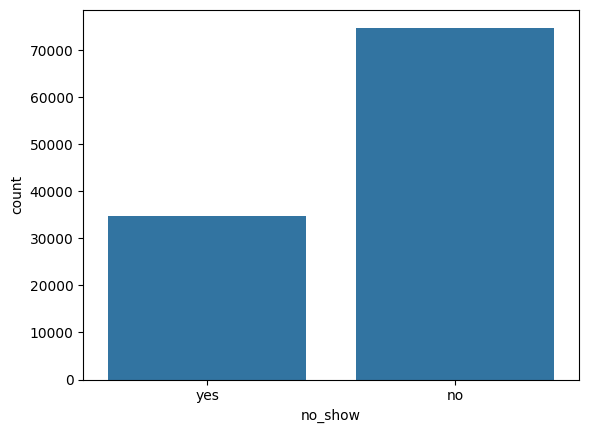

In [76]:
import seaborn as sns
sns.countplot(x='no_show', data=df)

<Axes: xlabel='no_show', ylabel='age'>

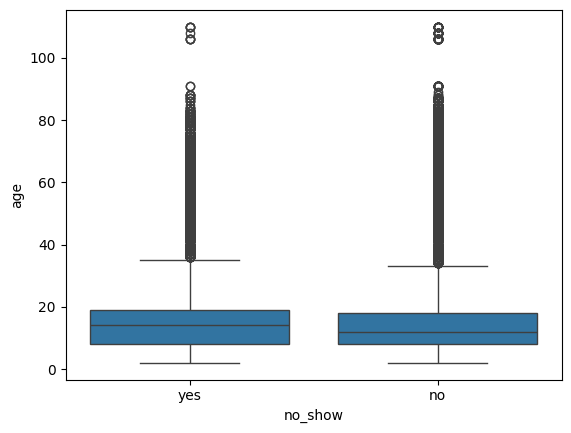

In [26]:
sns.boxplot(x='no_show', y='age', data=df)

In [121]:
df['age'].fillna(df['age'].median())
df['specialty'].fillna("Unknown")

0          psychotherapy
1                Unknown
2         speech therapy
3         speech therapy
4          physiotherapy
               ...      
109588     psychotherapy
109589    speech therapy
109590     psychotherapy
109591     physiotherapy
109592     psychotherapy
Name: specialty, Length: 109593, dtype: object

In [28]:
df

,specialty,appointment_time,gender,no_show,disability,place,appointment_shift,age,under_12_years_old,over_60_years_old,...,storm_day_before,rain_intensity,heat_intensity,appointment_date_continuous,Hipertension,Diabetes,Alcoholism,Handcap,Scholarship,SMS_received
0,psychotherapy,17,F,yes,intellectual,Lake Marvinville,afternoon,9.0,1,0,...,1,no_rain,warm,2020-01-01,0,0,0,0,0,0
1,NaN,7,M,no,intellectual,ITAPEMA,morning,11.0,1,0,...,1,no_rain,cold,2020-01-01,0,0,0,0,0,0
2,speech therapy,16,M,no,intellectual,ITAJAÍ,afternoon,8.0,1,0,...,1,no_rain,warm,2020-01-01,0,0,0,0,0,0
3,speech therapy,14,M,yes,intellectual,Sarahside,afternoon,9.0,1,0,...,1,moderate,mild,2020-01-01,0,0,0,0,0,1
4,physiotherapy,8,M,no,motor,ITAJAÍ,morning,NaN,0,0,...,1,no_rain,mild,2020-01-01,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109588,psychotherapy,16,M,yes,intellectual,NaN,afternoon,18.0,0,0,...,1,no_rain,mild,2021-05-11,0,0,0,0,0,0
109589,speech therapy,9,F,yes,motor,Port Georgestad,morning,18.0,0,0,...,1,moderate,warm,2021-05-11,0,0,0,0,0,0
109590,psychotherapy,13,F,no,intellectual,Erinton,afternoon,8.0,1,0,...,1,moderate,mild,2021-05-11,0,0,0,0,0,1
109591,physiotherapy,8,F,no,motor,CAMBORIU,morning,7.0,1,0,...,1,no_rain,warm,2021-05-11,0,0,0,0,0,0


In [122]:
df['no_show'] = df['no_show'].astype(str).str.strip().str.lower()
df

,specialty,appointment_time,gender,no_show,disability,place,appointment_shift,age,under_12_years_old,over_60_years_old,...,storm_day_before,rain_intensity,heat_intensity,appointment_date_continuous,Hipertension,Diabetes,Alcoholism,Handcap,Scholarship,SMS_received
0,psychotherapy,17,F,yes,intellectual,Lake Marvinville,afternoon,9.0,1,0,...,1,no_rain,warm,2020-01-01,0,0,0,0,0,0
1,NaN,7,M,no,intellectual,ITAPEMA,morning,11.0,1,0,...,1,no_rain,cold,2020-01-01,0,0,0,0,0,0
2,speech therapy,16,M,no,intellectual,ITAJAÍ,afternoon,8.0,1,0,...,1,no_rain,warm,2020-01-01,0,0,0,0,0,0
3,speech therapy,14,M,yes,intellectual,Sarahside,afternoon,9.0,1,0,...,1,moderate,mild,2020-01-01,0,0,0,0,0,1
4,physiotherapy,8,M,no,motor,ITAJAÍ,morning,NaN,0,0,...,1,no_rain,mild,2020-01-01,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109588,psychotherapy,16,M,yes,intellectual,NaN,afternoon,18.0,0,0,...,1,no_rain,mild,2021-05-11,0,0,0,0,0,0
109589,speech therapy,9,F,yes,motor,Port Georgestad,morning,18.0,0,0,...,1,moderate,warm,2021-05-11,0,0,0,0,0,0
109590,psychotherapy,13,F,no,intellectual,Erinton,afternoon,8.0,1,0,...,1,moderate,mild,2021-05-11,0,0,0,0,0,1
109591,physiotherapy,8,F,no,motor,CAMBORIU,morning,7.0,1,0,...,1,no_rain,warm,2021-05-11,0,0,0,0,0,0


In [123]:
df['no_show'].isna().sum()

np.int64(0)

In [124]:
print(df['no_show'].head())

0    yes
1     no
2     no
3    yes
4     no
Name: no_show, dtype: object


In [125]:
df['no_show'] = df['no_show'].str.strip().str.lower()
df['no_show'] = df['no_show'].map({'yes':1, 'no':0})

In [126]:
print(df['no_show'].head())
print(df['no_show'].isna().sum())

0    1
1    0
2    0
3    1
4    0
Name: no_show, dtype: int64
0


In [127]:
df

,specialty,appointment_time,gender,no_show,disability,place,appointment_shift,age,under_12_years_old,over_60_years_old,...,storm_day_before,rain_intensity,heat_intensity,appointment_date_continuous,Hipertension,Diabetes,Alcoholism,Handcap,Scholarship,SMS_received
0,psychotherapy,17,F,1,intellectual,Lake Marvinville,afternoon,9.0,1,0,...,1,no_rain,warm,2020-01-01,0,0,0,0,0,0
1,NaN,7,M,0,intellectual,ITAPEMA,morning,11.0,1,0,...,1,no_rain,cold,2020-01-01,0,0,0,0,0,0
2,speech therapy,16,M,0,intellectual,ITAJAÍ,afternoon,8.0,1,0,...,1,no_rain,warm,2020-01-01,0,0,0,0,0,0
3,speech therapy,14,M,1,intellectual,Sarahside,afternoon,9.0,1,0,...,1,moderate,mild,2020-01-01,0,0,0,0,0,1
4,physiotherapy,8,M,0,motor,ITAJAÍ,morning,NaN,0,0,...,1,no_rain,mild,2020-01-01,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109588,psychotherapy,16,M,1,intellectual,NaN,afternoon,18.0,0,0,...,1,no_rain,mild,2021-05-11,0,0,0,0,0,0
109589,speech therapy,9,F,1,motor,Port Georgestad,morning,18.0,0,0,...,1,moderate,warm,2021-05-11,0,0,0,0,0,0
109590,psychotherapy,13,F,0,intellectual,Erinton,afternoon,8.0,1,0,...,1,moderate,mild,2021-05-11,0,0,0,0,0,1
109591,physiotherapy,8,F,0,motor,CAMBORIU,morning,7.0,1,0,...,1,no_rain,warm,2021-05-11,0,0,0,0,0,0


EDA

<Axes: xlabel='no_show', ylabel='count'>

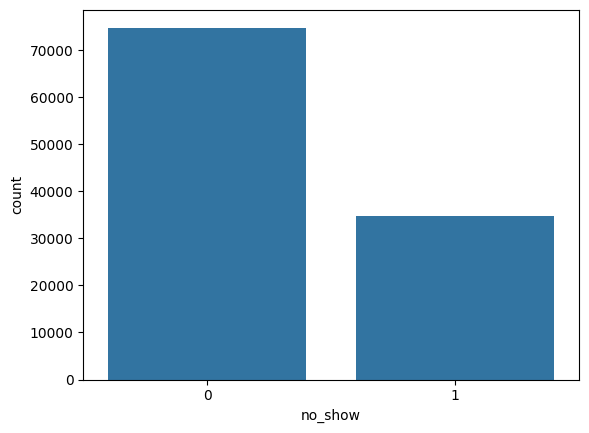

In [128]:
#NO-SHOW DISTRIUBUTION

import seaborn as sns
sns.countplot(x='no_show', data=df)

<Axes: xlabel='no_show', ylabel='age'>

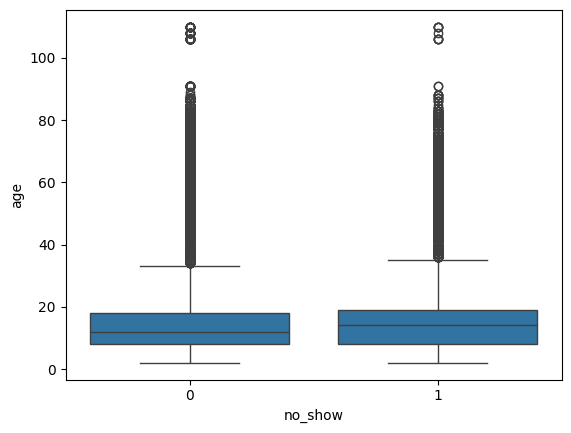

In [87]:
#Age vs No-show

sns.boxplot(x='no_show', y='age', data=df)

In [88]:
df

,specialty,appointment_time,gender,no_show,disability,place,appointment_shift,age,under_12_years_old,over_60_years_old,...,storm_day_before,rain_intensity,heat_intensity,appointment_date_continuous,Hipertension,Diabetes,Alcoholism,Handcap,Scholarship,SMS_received
0,psychotherapy,17,F,1,intellectual,Lake Marvinville,afternoon,9.0,1,0,...,1,no_rain,warm,2020-01-01,0,0,0,0,0,0
1,NaN,7,M,0,intellectual,ITAPEMA,morning,11.0,1,0,...,1,no_rain,cold,2020-01-01,0,0,0,0,0,0
2,speech therapy,16,M,0,intellectual,ITAJAÍ,afternoon,8.0,1,0,...,1,no_rain,warm,2020-01-01,0,0,0,0,0,0
3,speech therapy,14,M,1,intellectual,Sarahside,afternoon,9.0,1,0,...,1,moderate,mild,2020-01-01,0,0,0,0,0,1
4,physiotherapy,8,M,0,motor,ITAJAÍ,morning,NaN,0,0,...,1,no_rain,mild,2020-01-01,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109588,psychotherapy,16,M,1,intellectual,NaN,afternoon,18.0,0,0,...,1,no_rain,mild,2021-05-11,0,0,0,0,0,0
109589,speech therapy,9,F,1,motor,Port Georgestad,morning,18.0,0,0,...,1,moderate,warm,2021-05-11,0,0,0,0,0,0
109590,psychotherapy,13,F,0,intellectual,Erinton,afternoon,8.0,1,0,...,1,moderate,mild,2021-05-11,0,0,0,0,0,1
109591,physiotherapy,8,F,0,motor,CAMBORIU,morning,7.0,1,0,...,1,no_rain,warm,2021-05-11,0,0,0,0,0,0


<Axes: xlabel='SMS_received', ylabel='count'>

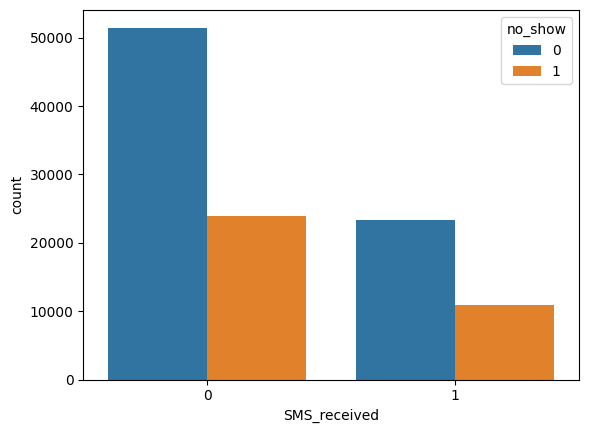

In [89]:
#SMS vs No-show (CORRECT COLUMN)

sns.countplot(x='SMS_received', hue='no_show', data=df)


<Axes: xlabel='count', ylabel='specialty'>

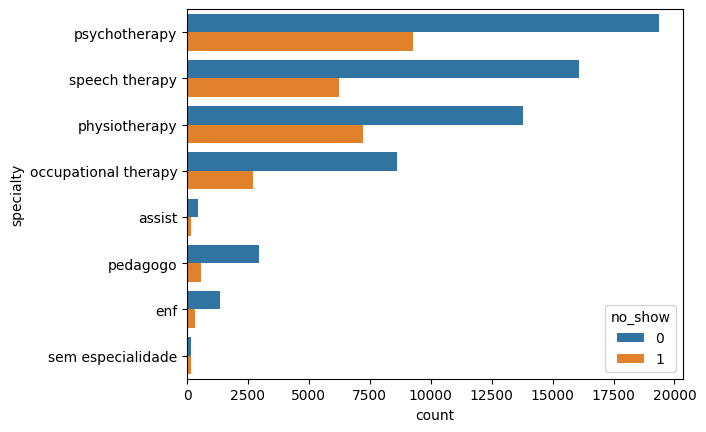

In [90]:
#Specialty vs No-show

sns.countplot(y='specialty', hue='no_show', data=df)

Handle Missing Values

In [129]:
# age
df['age'].fillna(df['age'].median())

# categorical
df['specialty'].fillna("Unknown")
df['disability'].fillna("Unknown")
df['place'].fillna("Unknown")

0         Lake Marvinville
1                  ITAPEMA
2                   ITAJAÍ
3                Sarahside
4                   ITAJAÍ
                ...       
109588             Unknown
109589     Port Georgestad
109590             Erinton
109591            CAMBORIU
109592             Unknown
Name: place, Length: 109593, dtype: object

In [130]:
df['age'] = df['age'].fillna(df['age'].median())

df['specialty'] = df['specialty'].fillna("Unknown")
df['disability'] = df['disability'].fillna("Unknown")
df['place'] = df['place'].fillna("Unknown")

In [131]:
df.isnull().sum()

specialty                         0
appointment_time                  0
gender                            0
no_show                           0
disability                        0
place                             0
appointment_shift                 0
age                               0
under_12_years_old                0
over_60_years_old                 0
patient_needs_companion           0
average_temp_day               2211
average_rain_day               2245
max_temp_day                   2227
max_rain_day                   2263
rainy_day_before                  0
storm_day_before                  0
rain_intensity                    0
heat_intensity                    0
appointment_date_continuous       0
Hipertension                      0
Diabetes                          0
Alcoholism                        0
Handcap                           0
Scholarship                       0
SMS_received                      0
dtype: int64

In [133]:
df['average_temp_day'] = df['average_temp_day'].fillna(df['average_temp_day'].median())

df['average_rain_day'] = df['average_rain_day'].fillna(df['average_rain_day'].median())

df['max_temp_day'] = df['max_temp_day'].fillna(df['max_temp_day'].median())

df['max_rain_day'] = df['max_rain_day'].fillna(df['max_rain_day'].median())
df

,specialty,appointment_time,gender,no_show,disability,place,appointment_shift,age,under_12_years_old,over_60_years_old,...,storm_day_before,rain_intensity,heat_intensity,appointment_date_continuous,Hipertension,Diabetes,Alcoholism,Handcap,Scholarship,SMS_received
0,psychotherapy,17,F,1,intellectual,Lake Marvinville,afternoon,9.0,1,0,...,1,no_rain,warm,2020-01-01,0,0,0,0,0,0
1,Unknown,7,M,0,intellectual,ITAPEMA,morning,11.0,1,0,...,1,no_rain,cold,2020-01-01,0,0,0,0,0,0
2,speech therapy,16,M,0,intellectual,ITAJAÍ,afternoon,8.0,1,0,...,1,no_rain,warm,2020-01-01,0,0,0,0,0,0
3,speech therapy,14,M,1,intellectual,Sarahside,afternoon,9.0,1,0,...,1,moderate,mild,2020-01-01,0,0,0,0,0,1
4,physiotherapy,8,M,0,motor,ITAJAÍ,morning,12.0,0,0,...,1,no_rain,mild,2020-01-01,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109588,psychotherapy,16,M,1,intellectual,Unknown,afternoon,18.0,0,0,...,1,no_rain,mild,2021-05-11,0,0,0,0,0,0
109589,speech therapy,9,F,1,motor,Port Georgestad,morning,18.0,0,0,...,1,moderate,warm,2021-05-11,0,0,0,0,0,0
109590,psychotherapy,13,F,0,intellectual,Erinton,afternoon,8.0,1,0,...,1,moderate,mild,2021-05-11,0,0,0,0,0,1
109591,physiotherapy,8,F,0,motor,CAMBORIU,morning,7.0,1,0,...,1,no_rain,warm,2021-05-11,0,0,0,0,0,0


In [134]:
# convert date
df['appointment_date_continuous'] = pd.to_datetime(df['appointment_date_continuous'])

# day of week
df['day_of_week'] = df['appointment_date_continuous'].dt.day_name()

# weekend
df['is_weekend'] = df['day_of_week'].isin(['Saturday','Sunday']).astype(int)

# rain flag
df['rain_flag'] = (df['average_rain_day'] > 0).astype(int)

# peak hour
df['is_peak_hour'] = df['appointment_time'].between(9,12).astype(int)
df

,specialty,appointment_time,gender,no_show,disability,place,appointment_shift,age,under_12_years_old,over_60_years_old,...,Hipertension,Diabetes,Alcoholism,Handcap,Scholarship,SMS_received,day_of_week,is_weekend,rain_flag,is_peak_hour
0,psychotherapy,17,F,1,intellectual,Lake Marvinville,afternoon,9.0,1,0,...,0,0,0,0,0,0,Wednesday,0,0,0
1,Unknown,7,M,0,intellectual,ITAPEMA,morning,11.0,1,0,...,0,0,0,0,0,0,Wednesday,0,1,0
2,speech therapy,16,M,0,intellectual,ITAJAÍ,afternoon,8.0,1,0,...,0,0,0,0,0,0,Wednesday,0,1,0
3,speech therapy,14,M,1,intellectual,Sarahside,afternoon,9.0,1,0,...,0,0,0,0,0,1,Wednesday,0,1,0
4,physiotherapy,8,M,0,motor,ITAJAÍ,morning,12.0,0,0,...,0,0,0,0,0,0,Wednesday,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109588,psychotherapy,16,M,1,intellectual,Unknown,afternoon,18.0,0,0,...,0,0,0,0,0,0,Tuesday,0,0,0
109589,speech therapy,9,F,1,motor,Port Georgestad,morning,18.0,0,0,...,0,0,0,0,0,0,Tuesday,0,1,1
109590,psychotherapy,13,F,0,intellectual,Erinton,afternoon,8.0,1,0,...,0,0,0,0,0,1,Tuesday,0,0,0
109591,physiotherapy,8,F,0,motor,CAMBORIU,morning,7.0,1,0,...,0,0,0,0,0,0,Tuesday,0,0,0


In [135]:
df = df.drop('appointment_date_continuous', axis=1)


In [136]:
#DROP HIGH-CARDINAL COLUMN (VERY IMPORTANT)
df = df.drop('place', axis=1)

In [137]:
categorical_cols = ['gender', 'specialty', 'appointment_shift', 
                    'disability', 'rain_intensity', 'heat_intensity', 'day_of_week']

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [138]:
df

,appointment_time,no_show,age,under_12_years_old,over_60_years_old,patient_needs_companion,average_temp_day,average_rain_day,max_temp_day,max_rain_day,...,heat_intensity_heavy_cold,heat_intensity_heavy_warm,heat_intensity_mild,heat_intensity_warm,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday
0,17,1,9.0,1,0,1,23.18,0.00,27.5,0.0,...,False,False,False,True,False,False,False,False,False,True
1,7,0,11.0,1,0,1,14.31,0.02,16.5,0.6,...,False,False,False,False,False,False,False,False,False,True
2,16,0,8.0,1,0,1,21.61,0.01,29.9,0.2,...,False,False,False,True,False,False,False,False,False,True
3,14,1,9.0,1,0,1,21.39,0.11,24.1,1.4,...,False,False,True,False,False,False,False,False,False,True
4,8,0,12.0,0,0,0,20.15,0.02,23.1,0.2,...,False,False,True,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109588,16,1,18.0,0,0,0,18.97,0.00,25.6,0.2,...,False,False,True,False,False,False,False,False,True,False
109589,9,1,18.0,0,0,0,24.46,0.23,31.4,8.7,...,False,False,False,True,False,False,False,False,True,False
109590,13,0,8.0,1,0,1,20.88,0.00,23.8,5.1,...,False,False,True,False,False,False,False,False,True,False
109591,8,0,7.0,1,0,1,24.89,0.00,28.8,0.0,...,False,False,False,True,False,False,False,False,True,False


In [48]:
!pip install scikit-learn

In [139]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = df.drop('no_show', axis=1)
y = df['no_show']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

model = RandomForestClassifier(class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [140]:

df.columns

Index(['appointment_time', 'no_show', 'age', 'under_12_years_old',
       'over_60_years_old', 'patient_needs_companion', 'average_temp_day',
       'average_rain_day', 'max_temp_day', 'max_rain_day', 'rainy_day_before',
       'storm_day_before', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap',
       'Scholarship', 'SMS_received', 'is_weekend', 'rain_flag',
       'is_peak_hour', 'gender_I', 'gender_M', 'specialty_assist',
       'specialty_enf', 'specialty_occupational therapy', 'specialty_pedagogo',
       'specialty_physiotherapy', 'specialty_psychotherapy',
       'specialty_sem especialidade', 'specialty_speech therapy',
       'appointment_shift_morning', 'disability_Unknown',
       'disability_intellectual', 'disability_motor',
       'rain_intensity_moderate', 'rain_intensity_no_rain',
       'rain_intensity_weak', 'heat_intensity_heavy_cold',
       'heat_intensity_heavy_warm', 'heat_intensity_mild',
       'heat_intensity_warm', 'day_of_week_Monday', 'day_of_week_Satur


Feature Engineering


CONTROLLED ENCODING (IMPORTANT)

In [141]:
#Split data

from sklearn.model_selection import train_test_split

X = df.drop('no_show', axis=1)
y = df['no_show']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [142]:
#Train model

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_estimators=100
)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [144]:
#Evaluate

from sklearn.metrics import classification_report, roc_auc_score

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

print("ROC AUC:", roc_auc_score(y_test, model.predict_proba(X_test)[:,1]))

              precision    recall  f1-score   support

           0       0.74      0.89      0.81     14952
           1       0.58      0.32      0.41      6967

    accuracy                           0.71     21919
   macro avg       0.66      0.61      0.61     21919
weighted avg       0.69      0.71      0.68     21919

ROC AUC: 0.748626190864016


In [145]:
y_prob = model.predict_proba(X_test)[:,1]

y_pred_new = (y_prob > 0.3).astype(int)

In [146]:
print(classification_report(y_test, y_pred_new))

              precision    recall  f1-score   support

           0       0.84      0.66      0.74     14952
           1       0.50      0.73      0.59      6967

    accuracy                           0.68     21919
   macro avg       0.67      0.69      0.66     21919
weighted avg       0.73      0.68      0.69     21919



In [60]:
pip install xgboost


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [148]:
#TRAIN MODEL

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    scale_pos_weight=2,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

xgb_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [149]:
#Evaluate

from sklearn.metrics import classification_report, roc_auc_score

y_pred_xgb = xgb_model.predict(X_test)

print(classification_report(y_test, y_pred_xgb))

print("ROC AUC:", roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:,1]))

              precision    recall  f1-score   support

           0       0.81      0.74      0.77     14952
           1       0.53      0.63      0.58      6967

    accuracy                           0.71     21919
   macro avg       0.67      0.69      0.68     21919
weighted avg       0.72      0.71      0.71     21919

ROC AUC: 0.7478192116116005


In [150]:
#Threshold tuning again
y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

y_pred_xgb_new = (y_prob_xgb > 0.3).astype(int)

print(classification_report(y_test, y_pred_xgb_new))

              precision    recall  f1-score   support

           0       0.91      0.31      0.46     14952
           1       0.39      0.93      0.55      6967

    accuracy                           0.51     21919
   macro avg       0.65      0.62      0.50     21919
weighted avg       0.74      0.51      0.49     21919



In [151]:
#Get importance

import pandas as pd

feature_importance = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance.head(10))

storm_day_before                  0.233340
disability_Unknown                0.108767
heat_intensity_heavy_cold         0.095793
age                               0.050353
rain_intensity_no_rain            0.048466
specialty_occupational therapy    0.031138
max_rain_day                      0.030513
specialty_pedagogo                0.027800
heat_intensity_mild               0.026825
average_rain_day                  0.025491
dtype: float32


<Axes: >

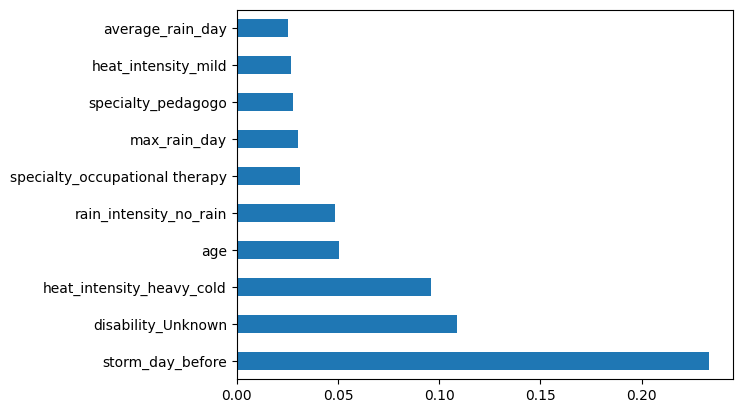

In [152]:
feature_importance.head(10).plot(kind='barh')

SMS reminders and weather conditions strongly influence patient attendance.

Demand Forecasting (Time Series)
Predict daily number of appointments

In [164]:
df_forecast['appointment_date_continuous'] = pd.to_datetime(df_forecast['appointment_date_continuous'])

daily_data = df_forecast.groupby('appointment_date_continuous').size().reset_index()

daily_data.columns = ['ds', 'y']

In [166]:
#Create train & test

train_size = int(len(daily_data) * 0.8)

train = daily_data[:train_size]
test = daily_data[train_size:]

TIME SERIES MODEL

In [165]:
#Prepare data
#The date column was converted into datetime format and set as the index to structure the data for time series modeling.
daily_data['ds'] = pd.to_datetime(daily_data['ds'])
daily_data.set_index('ds', inplace=True)

Build ARIMA Model

In [161]:
!pip install statsmodels


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip



   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 9.6/9.6 MB 54.2 MB/s  0:00:00

   ---------------------------------------- 0/2 [patsy]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsm

In [167]:
#An ARIMA model was used to capture temporal patterns and trends in the appointment data for forecasting.
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train['y'], order=(5,1,0))
model_fit = model.fit()

c:\Users\madhu\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\madhu\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\madhu\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Forecast future

In [169]:
#The trained ARIMA model was used to forecast future appointment demand for the test period.
forecast = model_fit.forecast(steps=len(test))

Evaluate model

In [171]:
#The model performance was evaluated using Mean Absolute Error (MAE), 
# which measures the average difference between predicted and actual values.
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(test['y'], forecast)
print("MAE:", mae)

MAE: 233.82090843591644


Save No-show model

In [172]:
#The classification model was saved using joblib to enable reuse during deployment.
import joblib

joblib.dump(xgb_model, "no_show_model.pkl")

['no_show_model.pkl']

Save Forecast model

In [174]:
#The forecasting model was saved to be used in the Streamlit application for future predictions.
joblib.dump(model_fit, "forecast_model.pkl")

['forecast_model.pkl']

STREAMLIT APP

In [175]:
!pip install streamlit


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [177]:
import joblib
joblib.dump(X.columns, "model_columns.pkl")

['model_columns.pkl']